# Johan Sebastian Mendieta Dilbert
# CC 11238908906

# Repaso de manejo de datos en Python

**Módulo 1 — Introducción · Curso Analítica de Datos**

Este notebook es material de **repaso** (no de introducción desde cero): asume que ya conoces la sintaxis básica de Python. El objetivo es refrescar y afianzar las herramientas que vamos a usar durante todo el curso — **NumPy**, **Pandas** y **Matplotlib** (con un vistazo a **Seaborn**) — antes de entrar a temas de analítica de datos propiamente dichos.

## Cómo está organizado

El notebook tiene **3 niveles progresivos**. Cada nivel cierra con un **ejercicio práctico** para que programes la solución tú mismo/a; guarda tu respuesta en la variable indicada y ejecuta `verificar_ejercicio_N()` para saber si está bien o mal, sin ver la respuesta correcta.

| Nivel | Contenido |
|---|---|
| 🟢 Básico | Repaso rápido de Python, NumPy, Series y DataFrame de Pandas, selección y filtrado |
| 🟡 Intermedio | Limpieza de datos, transformación, `groupby`, combinar tablas, gráficos básicos con Matplotlib |
| 🔴 Un poco avanzado | Series de tiempo, tablas dinámicas, visualización avanzada y Seaborn, mini-proyecto de EDA |

> 💡 Ejecuta las celdas en orden (Shift+Enter). Todas las celdas usan datos **sintéticos generados dentro del propio notebook**, así que no necesitas descargar ningún archivo externo.

## Preparación

Ejecuta esta celda antes de empezar. Si te falta alguna librería, instálala con `pip install pandas numpy matplotlib seaborn`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla fija para que los datos "aleatorios" sean siempre los mismos
np.random.seed(42)

# Ajustes de despliegue, solo para que las tablas se vean mejor en el notebook
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('Librerías cargadas correctamente ✅')
print('pandas', pd.__version__, '| numpy', np.__version__)

Librerías cargadas correctamente ✅
pandas 2.2.3 | numpy 2.1.3


### 🔍 Verificación automática de los ejercicios

Cada nivel incluye una función `verificar_ejercicio_N()` que revisa tus respuestas y te dice si están bien o mal (sin mostrarte la respuesta correcta, para que sigas practicando). Solo necesitas:

1. Guardar tus resultados en las variables con el **nombre exacto** que se indica en cada ejercicio.
2. Ejecutar la celda de verificación correspondiente.

Ejecuta la siguiente celda una sola vez — define las funciones de verificación que usaremos en los tres niveles.

In [ ]:
import hashlib
import json

def _huella(valor):
    # Convierte un resultado en un código corto para poder compararlo
    # sin dejar la respuesta correcta escrita en el notebook.
    texto = json.dumps(valor, sort_keys=True, default=str)
    return hashlib.sha256(texto.encode('utf-8')).hexdigest()[:12]

def _reportar(nombre, ok, pista=''):
    if ok:
        print(f'  ✅ {nombre}: ¡correcto!')
    else:
        extra = f' ({pista})' if pista else ''
        print(f'  ❌ {nombre}: no es el resultado esperado todavía{extra}.')
    return ok

print('Funciones de verificación listas ✅')

Funciones de verificación listas ✅


---
# 🟢 Nivel 1 — Básico

Repaso de estructuras de Python, NumPy y los primeros pasos con Pandas: crear un `DataFrame`, explorarlo y seleccionar/filtrar información.

## 1.1 Repaso rápido: listas, diccionarios y funciones

Estas son las estructuras de Python que más vamos a combinar con Pandas.

In [ ]:
# Listas: colección ordenada y modificable
productos = ['Teclado', 'Mouse', 'Monitor', 'Audífonos']
precios = [85000, 45000, 620000, 120000]

# Comprensión de listas: forma compacta de transformar una lista
precios_con_iva = [p * 1.19 for p in precios]
print('Precios con IVA:', precios_con_iva)

# Diccionarios: pares clave-valor (muy parecido a una fila de una tabla)
producto_info = {'nombre': 'Teclado', 'precio': 85000, 'categoria': 'Periféricos'}
print(producto_info['nombre'], '->', producto_info['precio'])

# Una función simple, la usaremos más adelante con Pandas (apply)
def aplicar_descuento(precio, porcentaje=0.10):
    # Devuelve el precio con un descuento aplicado
    return precio * (1 - porcentaje)

print('Precio con descuento:', aplicar_descuento(85000, 0.15))

Precios con IVA: [101150.0, 53550.0, 737800.0, 142800.0]
Teclado -> 85000
Precio con descuento: 72250.0


## 1.2 NumPy: arrays y operaciones vectorizadas

Pandas está construido sobre NumPy. La gran diferencia frente a una lista de Python es que las operaciones sobre un `array` se aplican a **todos los elementos a la vez** (vectorización), sin necesidad de escribir un bucle `for`.

In [ ]:
precios_array = np.array(precios)
print('Array:', precios_array)
print('Tipo de dato:', precios_array.dtype)

# Operaciones vectorizadas: se aplican a todo el array de una vez
print('Con IVA (vectorizado):', precios_array * 1.19)
print('Precio mínimo:', precios_array.min())
print('Precio máximo:', precios_array.max())
print('Precio promedio:', precios_array.mean())

# Indexado y slicing, igual que en listas
print('Primeros dos precios:', precios_array[:2])

# Filtrado booleano: el corazón de cómo se filtra en Pandas
caros = precios_array[precios_array > 100000]
print('Productos con precio > 100000:', caros)

Array: [ 85000  45000 620000 120000]
Tipo de dato: int64
Con IVA (vectorizado): [101150.  53550. 737800. 142800.]
Precio mínimo: 45000
Precio máximo: 620000
Precio promedio: 217500.0
Primeros dos precios: [85000 45000]
Productos con precio > 100000: [620000 120000]


## 1.3 Introducción a Pandas: `Series` y `DataFrame`

- Una **`Series`** es como una columna: una lista de valores con un índice.
- Un **`DataFrame`** es una tabla: varias `Series` que comparten el mismo índice (filas) y tienen nombre (columnas).

Vamos a crear un pequeño registro de ventas de una tienda de tecnología.

In [ ]:
ventas_dict = {
    'fecha': pd.to_datetime([
        '2026-01-05', '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-07',
        '2026-01-08', '2026-01-09', '2026-01-09', '2026-01-10', '2026-01-11',
        '2026-01-11', '2026-01-12',
    ]),
    'producto': ['Teclado', 'Mouse', 'Monitor', 'Audífonos', 'Teclado',
                 'Monitor', 'Mouse', 'Audífonos', 'Teclado', 'Monitor',
                 'Mouse', 'Audífonos'],
    'categoria': ['Periféricos', 'Periféricos', 'Pantallas', 'Audio', 'Periféricos',
                  'Pantallas', 'Periféricos', 'Audio', 'Periféricos', 'Pantallas',
                  'Periféricos', 'Audio'],
    'cantidad': [2, 5, 1, 3, 1, 2, 4, 2, 3, 1, 6, 2],
    'precio_unitario': [85000, 45000, 620000, 120000, 85000,
                         620000, 45000, 120000, 85000, 620000,
                         45000, 120000],
}

ventas = pd.DataFrame(ventas_dict)
ventas

,fecha,producto,categoria,cantidad,precio_unitario
0,2026-01-05,Teclado,Periféricos,2,85000
1,2026-01-05,Mouse,Periféricos,5,45000
2,2026-01-06,Monitor,Pantallas,1,620000
3,2026-01-07,Audífonos,Audio,3,120000
4,2026-01-07,Teclado,Periféricos,1,85000
5,2026-01-08,Monitor,Pantallas,2,620000
6,2026-01-09,Mouse,Periféricos,4,45000
7,2026-01-09,Audífonos,Audio,2,120000
8,2026-01-10,Teclado,Periféricos,3,85000
9,2026-01-11,Monitor,Pantallas,1,620000


In [ ]:
# Explorar el DataFrame
print('Forma (filas, columnas):', ventas.shape)
print('\nColumnas:', list(ventas.columns))
print('\nTipos de dato:')
print(ventas.dtypes)

Forma (filas, columnas): (12, 5)

Columnas: ['fecha', 'producto', 'categoria', 'cantidad', 'precio_unitario']

Tipos de dato:
fecha              datetime64[ns]
producto                   object
categoria                  object
cantidad                    int64
precio_unitario             int64
dtype: object


In [ ]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            12 non-null     datetime64[ns]
 1   producto         12 non-null     object        
 2   categoria        12 non-null     object        
 3   cantidad         12 non-null     int64         
 4   precio_unitario  12 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 612.0+ bytes


In [ ]:
# describe() da un resumen estadístico rápido de las columnas numéricas
ventas.describe()

,fecha,cantidad,precio_unitario
count,12,12.000000,12.000000
mean,2026-01-08 08:00:00,2.666667,217500.000000
min,2026-01-05 00:00:00,1.000000,45000.000000
25%,2026-01-06 18:00:00,1.750000,75000.000000
50%,2026-01-08 12:00:00,2.000000,102500.000000
75%,2026-01-10 06:00:00,3.250000,245000.000000
max,2026-01-12 00:00:00,6.000000,620000.000000
std,NaN,1.614330,244293.973431


## 1.4 Selección y filtrado básico

Las formas más comunes de acceder a datos en un `DataFrame`:

- `df['columna']` → selecciona una columna (devuelve una `Series`)
- `df[['col1', 'col2']]` → selecciona varias columnas (devuelve un `DataFrame`)
- `df.loc[filas, columnas]` → selección **por etiqueta**
- `df.iloc[filas, columnas]` → selección **por posición**
- `df[condición_booleana]` → filtrado

In [ ]:
# Seleccionar una columna
print(ventas['producto'].head())

# Seleccionar varias columnas
ventas[['producto', 'cantidad']].head()

0      Teclado
1        Mouse
2      Monitor
3    Audífonos
4      Teclado
Name: producto, dtype: object


,producto,cantidad
0,Teclado,2
1,Mouse,5
2,Monitor,1
3,Audífonos,3
4,Teclado,1


In [ ]:
# loc: por etiqueta (aquí el índice es numérico, pero funciona igual)
print(ventas.loc[0:2, ['producto', 'categoria']])

# iloc: por posición (fila 0 a 2, columnas 1 a 2)
print(ventas.iloc[0:3, 1:3])

  producto    categoria
0  Teclado  Periféricos
1    Mouse  Periféricos
2  Monitor    Pantallas
  producto    categoria
0  Teclado  Periféricos
1    Mouse  Periféricos
2  Monitor    Pantallas


In [ ]:
# Filtrado booleano: solo ventas de la categoría "Periféricos"
perifericos = ventas[ventas['categoria'] == 'Periféricos']
perifericos

,fecha,producto,categoria,cantidad,precio_unitario
0,2026-01-05,Teclado,Periféricos,2,85000
1,2026-01-05,Mouse,Periféricos,5,45000
4,2026-01-07,Teclado,Periféricos,1,85000
6,2026-01-09,Mouse,Periféricos,4,45000
8,2026-01-10,Teclado,Periféricos,3,85000
10,2026-01-11,Mouse,Periféricos,6,45000


In [ ]:
# Crear una columna nueva calculada a partir de otras
ventas['total'] = ventas['cantidad'] * ventas['precio_unitario']
ventas.head()

,fecha,producto,categoria,cantidad,precio_unitario,total
0,2026-01-05,Teclado,Periféricos,2,85000,170000
1,2026-01-05,Mouse,Periféricos,5,45000,225000
2,2026-01-06,Monitor,Pantallas,1,620000,620000
3,2026-01-07,Audífonos,Audio,3,120000,360000
4,2026-01-07,Teclado,Periféricos,1,85000,85000


### 📝 Ejercicio — Nivel 1 (básico)

Usando el DataFrame `ventas` que acabamos de crear, escribe código para responder. **Guarda cada respuesta en la variable indicada** para poder verificarlas automáticamente:

1. ¿Cuántas ventas (filas) hay de la categoría `"Audio"`? → variable **`n_audio`**
2. ¿Cuál es el **total vendido** (columna `total`) sumando todas las filas? → variable **`total_general`**
3. Filtra las ventas donde `cantidad` sea mayor o igual a 4. → variable **`alta_cantidad`** (un DataFrame)
4. Ordena el DataFrame por `total` de mayor a menor y muestra las 3 ventas más altas. → variable **`top_3`** (un DataFrame)

Escribe tu código en la celda de abajo (puedes usar varias celdas si prefieres).

In [ ]:
n_audio = ventas[ventas['categoria'] == 'Audio'].shape[0]
total_general = ventas['total'].sum()
alta_cantidad = ventas[ventas['cantidad'] >= 4]
top_3 = ventas.sort_values(by='total', ascending=False).head(3)

Cuando tengas las 4 variables listas, ejecuta esta celda para verificar tus respuestas:

In [ ]:
def verificar_ejercicio_1():
    print('Verificando Ejercicio 1...')
    ok = True

    if 'n_audio' in globals():
        ok &= _reportar('n_audio', _huella(round(float(n_audio))) == '4e07408562be', 'revisa el filtro por categoría')
    else:
        ok = _reportar('n_audio', False, 'no has definido esta variable')

    if 'total_general' in globals():
        ok &= _reportar('total_general', _huella(round(float(total_general))) == '8b55667f1a3f', "revisa que estés sumando la columna 'total' completa")
    else:
        ok = _reportar('total_general', False, 'no has definido esta variable')

    if 'alta_cantidad' in globals():
        idx = sorted(int(i) for i in alta_cantidad.index)
        ok &= _reportar('alta_cantidad', _huella(idx) == '6ba084f802d3', 'revisa la condición del filtro (>= 4)')
    else:
        ok = _reportar('alta_cantidad', False, 'no has definido esta variable')

    if 'top_3' in globals():
        idx = [int(i) for i in top_3.index]
        ok &= _reportar('top_3', _huella(idx) == '86ef4ca08629', 'revisa que estés ordenando de mayor a menor y tomando solo 3 filas')
    else:
        ok = _reportar('top_3', False, 'no has definido esta variable')

    print('🎉 ¡Todo correcto!' if ok else 'Sigue intentando, revisa las pistas de arriba.')

verificar_ejercicio_1()

Verificando Ejercicio 1...
  ✅ n_audio: ¡correcto!
  ✅ total_general: ¡correcto!
  ✅ alta_cantidad: ¡correcto!
  ✅ top_3: ¡correcto!
🎉 ¡Todo correcto!


---
# 🟡 Nivel 2 — Intermedio

En la vida real los datos casi nunca llegan limpios. En este nivel simulamos un dataset más grande y "sucio" (con valores faltantes y duplicados), lo limpiamos, lo transformamos, lo agrupamos y lo combinamos con otra tabla. Cerramos con los primeros gráficos en Matplotlib.

## 2.1 Generar un dataset más grande (y un poco "sucio")

Generamos 200 ventas distribuidas en 3 meses, y a propósito dañamos algunos datos (`NaN` y filas duplicadas) para practicar limpieza — así es como suelen llegar los datos reales.

In [ ]:
# Reseeamos aquí para que esta sección dé siempre los mismos datos,
# sin importar cuántas veces hayas ejecutado celdas anteriores.
np.random.seed(42)

n = 200
productos_cat = {
    'Teclado': 'Periféricos', 'Mouse': 'Periféricos', 'Monitor': 'Pantallas',
    'Audífonos': 'Audio', 'Parlante': 'Audio', 'Webcam': 'Periféricos',
}
precio_base = {
    'Teclado': 85000, 'Mouse': 45000, 'Monitor': 620000,
    'Audífonos': 120000, 'Parlante': 95000, 'Webcam': 150000,
}
regiones = ['Andina', 'Caribe', 'Pacífica', 'Orinoquía']

productos_random = np.random.choice(list(productos_cat.keys()), size=n)
fechas_random = pd.to_datetime('2026-01-01') + pd.to_timedelta(
    np.random.randint(0, 90, size=n), unit='D'
)

ventas_grande = pd.DataFrame({
    'fecha': fechas_random,
    'producto': productos_random,
    'categoria': [productos_cat[p] for p in productos_random],
    'region': np.random.choice(regiones, size=n),
    'cantidad': np.random.randint(1, 8, size=n),
    'precio_unitario': [precio_base[p] * np.random.uniform(0.95, 1.05) for p in productos_random],
})

# Dañamos el dataset a propósito: algunos NaN en 'cantidad' y 'region'
nan_idx_cantidad = np.random.choice(ventas_grande.index, size=8, replace=False)
ventas_grande.loc[nan_idx_cantidad, 'cantidad'] = np.nan

nan_idx_region = np.random.choice(ventas_grande.index, size=5, replace=False)
ventas_grande.loc[nan_idx_region, 'region'] = np.nan

# Y agregamos filas duplicadas
duplicados = ventas_grande.sample(6, random_state=1)
ventas_grande = pd.concat([ventas_grande, duplicados], ignore_index=True)

print('Forma del dataset (con nulos y duplicados):', ventas_grande.shape)
ventas_grande.head(10)

Forma del dataset (con nulos y duplicados): (206, 6)


,fecha,producto,categoria,region,cantidad,precio_unitario
0,2026-02-01,Audífonos,Audio,Caribe,4.0,117119.398354
1,2026-03-29,Parlante,Audio,Pacífica,2.0,94555.788045
2,2026-02-21,Monitor,Pantallas,Caribe,5.0,591003.588969
3,2026-03-03,Parlante,Audio,Andina,1.0,92907.753318
4,2026-02-27,Parlante,Audio,Caribe,3.0,94156.463848
5,2026-02-21,Mouse,Periféricos,Caribe,1.0,45462.518469
6,2026-01-12,Monitor,Pantallas,Caribe,3.0,605799.373836
7,2026-02-08,Monitor,Pantallas,Caribe,4.0,597257.477764
8,2026-01-02,Monitor,Pantallas,Andina,2.0,593724.423535
9,2026-01-03,Parlante,Audio,Orinoquía,1.0,99185.052358


## 2.2 Limpieza de datos

Pasos típicos: detectar valores faltantes, decidir si eliminarlos o imputarlos, y eliminar duplicados.

In [ ]:
# ¿Cuántos valores faltantes hay por columna?
ventas_grande.isna().sum()

,0
fecha,0
producto,0
categoria,0
region,5
cantidad,10
precio_unitario,0


In [ ]:
# ¿Cuántas filas están completamente duplicadas?
print('Filas duplicadas:', ventas_grande.duplicated().sum())

# Eliminarlas, quedándonos con la primera aparición
ventas_limpio = ventas_grande.drop_duplicates().copy()
print('Forma tras quitar duplicados:', ventas_limpio.shape)

Filas duplicadas: 6
Forma tras quitar duplicados: (200, 6)


In [ ]:
# 'cantidad' es numérica: imputamos con la mediana (más robusta que la media ante outliers)
mediana_cantidad = ventas_limpio['cantidad'].median()
ventas_limpio['cantidad'] = ventas_limpio['cantidad'].fillna(mediana_cantidad)

# 'region' es categórica: no tiene sentido "inventar" una región, así que eliminamos esas filas
ventas_limpio = ventas_limpio.dropna(subset=['region'])

print('Nulos restantes:')
print(ventas_limpio.isna().sum())
print('\nForma final:', ventas_limpio.shape)

Nulos restantes:
fecha              0
producto           0
categoria          0
region             0
cantidad           0
precio_unitario    0
dtype: int64

Forma final: (195, 6)


## 2.3 Transformación de datos

`apply` ejecuta una función sobre cada valor de una columna (o cada fila, con `axis=1`); `map` es una versión más simple pensada para transformar valores uno a uno.

In [ ]:
# Asegurar el tipo numérico correcto tras la limpieza
ventas_limpio['cantidad'] = ventas_limpio['cantidad'].astype(int)

# Nueva columna con apply + la función que definimos en el Nivel 1
ventas_limpio['precio_con_descuento'] = ventas_limpio['precio_unitario'].apply(aplicar_descuento)

# map: traducir cada región a su abreviatura
abreviaturas = {'Andina': 'AND', 'Caribe': 'CAR', 'Pacífica': 'PAC', 'Orinoquía': 'ORI'}
ventas_limpio['region_abrev'] = ventas_limpio['region'].map(abreviaturas)

ventas_limpio['total'] = ventas_limpio['cantidad'] * ventas_limpio['precio_unitario']
ventas_limpio[['producto', 'region', 'region_abrev', 'cantidad', 'precio_con_descuento', 'total']].head()

,producto,region,region_abrev,cantidad,precio_con_descuento,total
0,Audífonos,Caribe,CAR,4,105407.458519,4.684776e+05
1,Parlante,Pacífica,PAC,2,85100.209240,1.891116e+05
2,Monitor,Caribe,CAR,5,531903.230072,2.955018e+06
3,Parlante,Andina,AND,1,83616.977986,9.290775e+04
4,Parlante,Caribe,CAR,3,84740.817463,2.824694e+05


## 2.4 Agrupación y agregación con `groupby`

`groupby` sigue el patrón **dividir → aplicar → combinar**: divide el DataFrame en grupos, aplica una función de agregación a cada grupo, y combina los resultados en una tabla nueva.

In [ ]:
# Total vendido por categoría, ordenado de mayor a menor
total_por_categoria = ventas_limpio.groupby('categoria')['total'].sum().sort_values(ascending=False)
print(total_por_categoria)

categoria
Pantallas      8.380256e+07
Periféricos    3.407093e+07
Audio          3.111881e+07
Name: total, dtype: float64


In [ ]:
# Varias agregaciones a la vez con .agg()
resumen_region = ventas_limpio.groupby('region').agg(
    total_vendido=('total', 'sum'),
    ventas_realizadas=('total', 'count'),
    ticket_promedio=('total', 'mean'),
).round(0)
resumen_region

,total_vendido,ventas_realizadas,ticket_promedio
region,,,
Andina,30039866.0,53,566790.0
Caribe,53002443.0,55,963681.0
Orinoquía,43523528.0,51,853403.0
Pacífica,22426470.0,36,622957.0


In [ ]:
# value_counts: conteo rápido de valores únicos de una columna
ventas_limpio['producto'].value_counts()

,count
producto,
Audífonos,41
Parlante,32
Monitor,32
Teclado,32
Webcam,30
Mouse,28


## 2.5 Combinar DataFrames con `merge`

Es habitual tener la información repartida en varias tablas (por ejemplo, una tabla de hechos y una tabla de referencia). Simulemos una tabla con el encargado de ventas por región.

In [ ]:
encargados = pd.DataFrame({
    'region': ['Andina', 'Caribe', 'Pacífica', 'Orinoquía'],
    'encargado': ['Laura Gómez', 'Carlos Pérez', 'Ana Rodríguez', 'Julián Torres'],
})

# merge tipo 'left': conserva todas las filas de ventas_limpio y les agrega el encargado
ventas_con_encargado = ventas_limpio.merge(encargados, on='region', how='left')
ventas_con_encargado[['fecha', 'producto', 'region', 'encargado', 'total']].head()

,fecha,producto,region,encargado,total
0,2026-02-01,Audífonos,Caribe,Carlos Pérez,4.684776e+05
1,2026-03-29,Parlante,Pacífica,Ana Rodríguez,1.891116e+05
2,2026-02-21,Monitor,Caribe,Carlos Pérez,2.955018e+06
3,2026-03-03,Parlante,Andina,Laura Gómez,9.290775e+04
4,2026-02-27,Parlante,Caribe,Carlos Pérez,2.824694e+05


## 2.6 Visualización básica con Matplotlib

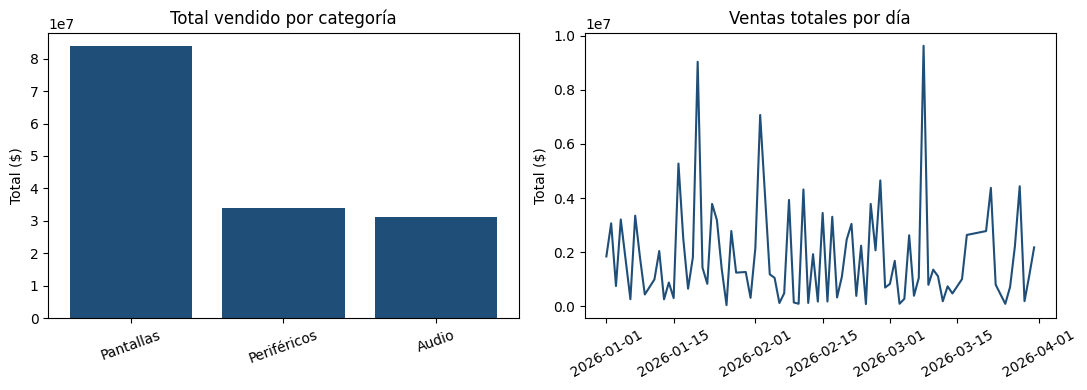

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico de barras: total vendido por categoría
axes[0].bar(total_por_categoria.index, total_por_categoria.values, color='#1f4e78')
axes[0].set_title('Total vendido por categoría')
axes[0].set_ylabel('Total ($)')
axes[0].tick_params(axis='x', rotation=20)

# Línea de tendencia: ventas totales por día
ventas_por_dia = ventas_limpio.groupby('fecha')['total'].sum().sort_index()
axes[1].plot(ventas_por_dia.index, ventas_por_dia.values, color='#1f4e78')
axes[1].set_title('Ventas totales por día')
axes[1].set_ylabel('Total ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

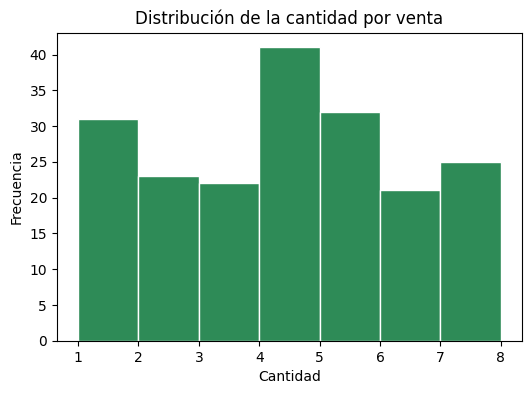

In [ ]:
# Histograma: distribución de la cantidad vendida por transacción
plt.figure(figsize=(6, 4))
plt.hist(ventas_limpio['cantidad'], bins=range(1, 9), color='#2e8b57', edgecolor='white')
plt.title('Distribución de la cantidad por venta')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()

### 📝 Ejercicio — Nivel 2 (intermedio)

Trabaja sobre `ventas_con_encargado` (ya está limpio) y resuelve. **Guarda tus respuestas en las variables indicadas:**

1. Calcula el **total vendido por encargado** (`groupby` + `sum`), ordenado de mayor a menor. → variable **`total_por_encargado`**
2. Crea una columna `mes` a partir de `fecha` (pista: `ventas_con_encargado['fecha'].dt.month`) y calcula el total vendido por mes. → variable **`total_por_mes`**
3. Haz un gráfico de **barras** con el total vendido por encargado.
4. Haz un gráfico de **línea** con el total vendido por mes.

(Los gráficos no se verifican automáticamente — compáralos a simple vista con la solución. Las variables `total_por_encargado` y `total_por_mes` sí las revisa `verificar_ejercicio_2()`.)

Escribe tu código en la celda de abajo.

/tmp/ipykernel_1235/497820048.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_por_encargado.index, y=total_por_encargado.values, palette='viridis')


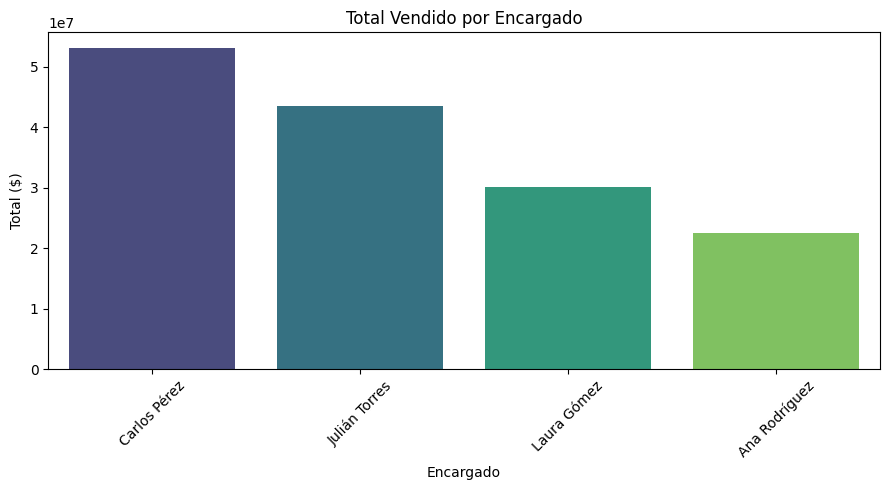

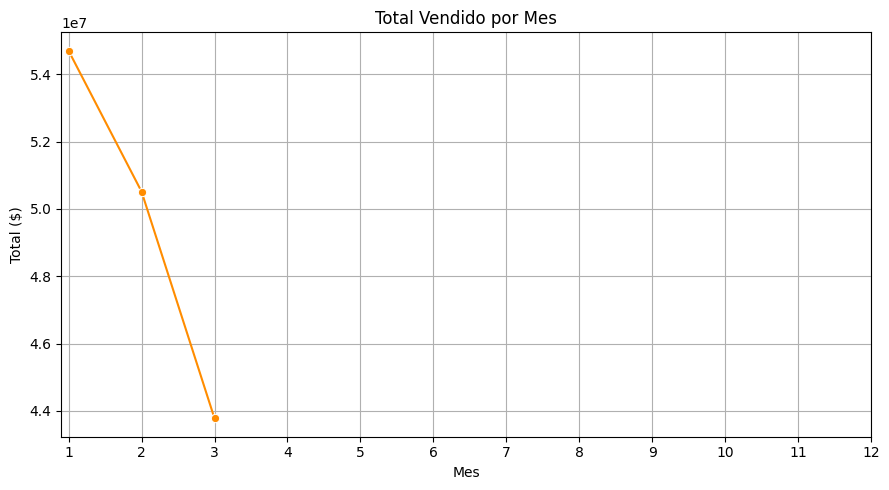

In [ ]:
total_por_encargado = ventas_con_encargado.groupby('encargado')['total'].sum().sort_values(ascending=False)

ventas_con_encargado['mes'] = ventas_con_encargado['fecha'].dt.month
total_por_mes = ventas_con_encargado.groupby('mes')['total'].sum()

# Gráfico de barras para total_por_encargado
plt.figure(figsize=(9, 5))
sns.barplot(x=total_por_encargado.index, y=total_por_encargado.values, palette='viridis')
plt.title('Total Vendido por Encargado')
plt.xlabel('Encargado')
plt.ylabel('Total ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico de línea para total_por_mes
plt.figure(figsize=(9, 5))
sns.lineplot(x=total_por_mes.index, y=total_por_mes.values, marker='o', color='darkorange')
plt.title('Total Vendido por Mes')
plt.xlabel('Mes')
plt.ylabel('Total ($)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

Cuando tengas `total_por_encargado` y `total_por_mes` listos, ejecuta esta celda:

In [ ]:
def verificar_ejercicio_2():
    print('Verificando Ejercicio 2...')
    ok = True

    if 'total_por_encargado' in globals():
        pares = sorted([[str(k), round(float(v))] for k, v in total_por_encargado.items()])
        orden_ok = list(total_por_encargado.values) == sorted(total_por_encargado.values, reverse=True)
        valores_ok = _huella(pares) == 'ca2f8134cdd3'
        ok &= _reportar('total_por_encargado', valores_ok and orden_ok,
                         'revisa los valores' if not valores_ok else 'falta ordenar de mayor a menor')
    else:
        ok = _reportar('total_por_encargado', False, 'no has definido esta variable')

    if 'total_por_mes' in globals():
        pares = sorted([[int(k), round(float(v))] for k, v in total_por_mes.items()])
        ok &= _reportar('total_por_mes', _huella(pares) == 'e3b5d58d5ab0', 'revisa el cálculo por mes')
    else:
        ok = _reportar('total_por_mes', False, 'no has definido esta variable')

    print('🎉 ¡Todo correcto! (recuerda revisar tus 2 gráficos a simple vista)' if ok else 'Sigue intentando, revisa las pistas de arriba.')

verificar_ejercicio_2()

Verificando Ejercicio 2...
  ✅ total_por_encargado: ¡correcto!
  ✅ total_por_mes: ¡correcto!
🎉 ¡Todo correcto! (recuerda revisar tus 2 gráficos a simple vista)


---
# 🔴 Nivel 3 — Un poco avanzado

Cerramos el repaso con series de tiempo, tablas dinámicas, visualización más elaborada (incluyendo Seaborn) y un mini flujo de análisis exploratorio de datos (EDA) de principio a fin.

## 3.1 Series de tiempo con Pandas

Cuando la columna de fecha es el índice, Pandas ofrece herramientas muy cómodas para trabajar por periodos (`resample`) y calcular promedios móviles (`rolling`).

fecha
2026-01-04    8.862026e+06
2026-01-11    6.834153e+06
2026-01-18    1.190863e+07
2026-01-25    2.144676e+07
2026-02-01    7.799813e+06
Freq: W-SUN, Name: total, dtype: float64


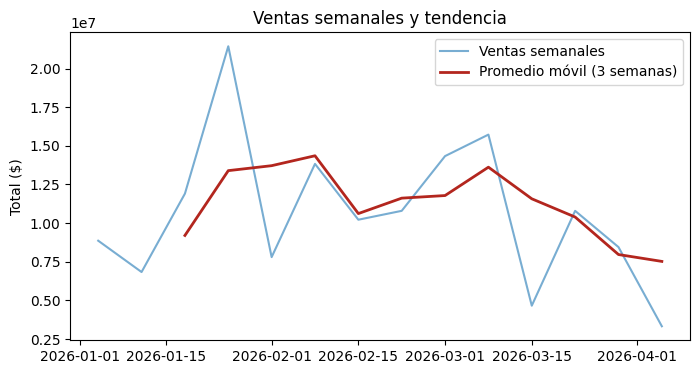

In [ ]:
serie_diaria = ventas_limpio.set_index('fecha')['total'].sort_index()

# resample('W'): agrupa por semana y suma
ventas_semanales = serie_diaria.resample('W').sum()
print(ventas_semanales.head())

# rolling: promedio móvil de 3 periodos, útil para suavizar una serie ruidosa
promedio_movil = ventas_semanales.rolling(window=3).mean()

plt.figure(figsize=(8, 4))
plt.plot(ventas_semanales.index, ventas_semanales.values, label='Ventas semanales', alpha=0.6)
plt.plot(promedio_movil.index, promedio_movil.values, label='Promedio móvil (3 semanas)', color='#b3261e', linewidth=2)
plt.title('Ventas semanales y tendencia')
plt.ylabel('Total ($)')
plt.legend()
plt.show()

## 3.2 Tablas dinámicas con `pivot_table`

Una tabla dinámica cruza dos variables categóricas y resume una tercera — el equivalente en Pandas a una tabla dinámica de Excel.

In [ ]:
tabla_dinamica = ventas_con_encargado.pivot_table(
    index='region',
    columns='categoria',
    values='total',
    aggfunc='sum',
    fill_value=0,
)
tabla_dinamica

categoria,Audio,Pantallas,Periféricos
region,,,
Andina,7.889421e+06,1.218673e+07,9.963713e+06
Caribe,1.011490e+07,3.618739e+07,6.700150e+06
Orinoquía,5.714451e+06,2.583267e+07,1.197640e+07
Pacífica,7.400041e+06,9.595759e+06,5.430670e+06


In [ ]:
# crosstab con normalize: distribución porcentual de ventas por región y categoría
pd.crosstab(
    ventas_con_encargado['region'],
    ventas_con_encargado['categoria'],
    normalize='index',
).round(2)

categoria,Audio,Pantallas,Periféricos
region,,,
Andina,0.40,0.09,0.51
Caribe,0.35,0.27,0.38
Orinoquía,0.31,0.18,0.51
Pacífica,0.47,0.08,0.44


## 3.3 `apply` sobre filas (`axis=1`) y funciones más elaboradas

Con `axis=1`, `apply` recibe **la fila completa**, lo que permite lógica que combina varias columnas.

In [ ]:
def clasificar_venta(fila):
    if fila['total'] >= 500000:
        return 'Alta'
    elif fila['total'] >= 150000:
        return 'Media'
    return 'Baja'

ventas_con_encargado['nivel_venta'] = ventas_con_encargado.apply(clasificar_venta, axis=1)
ventas_con_encargado['nivel_venta'].value_counts()

,count
nivel_venta,
Alta,86
Media,72
Baja,37


## 3.4 Visualización avanzada y un vistazo a Seaborn

Matplotlib permite personalizar prácticamente cualquier detalle de una figura; Seaborn simplifica gráficos estadísticos comunes (como mapas de calor o boxplots) construidos sobre Matplotlib.

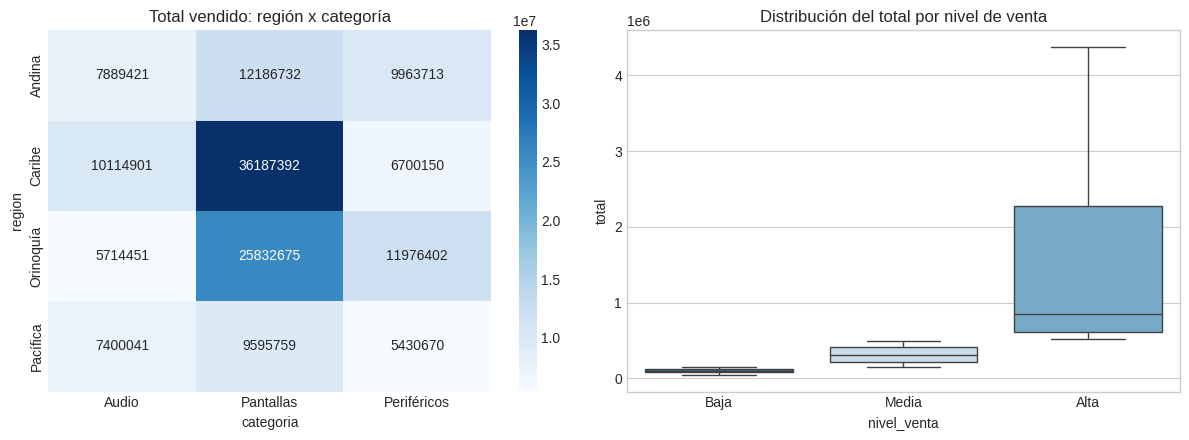

Figura guardada como 'resumen_ventas.png'


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Heatmap de la tabla dinámica con Seaborn
sns.heatmap(tabla_dinamica, annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Total vendido: región x categoría')

# Boxplot con Seaborn: distribución del total por nivel de venta
sns.boxplot(data=ventas_con_encargado, x='nivel_venta', y='total',
            order=['Baja', 'Media', 'Alta'], hue='nivel_venta',
            palette='Blues', legend=False, ax=axes[1])
axes[1].set_title('Distribución del total por nivel de venta')

plt.tight_layout()
plt.show()

# Guardar una figura a archivo (útil para incluirla en un informe)
fig.savefig('resumen_ventas.png', dpi=150, bbox_inches='tight')
print("Figura guardada como 'resumen_ventas.png'")

## 3.5 Mini flujo integrador: un EDA de principio a fin

Generamos un dataset nuevo, más grande y de un año completo, y recorremos rápidamente el flujo típico de un análisis exploratorio: **cargar → limpiar → transformar → agrupar → visualizar → concluir**.

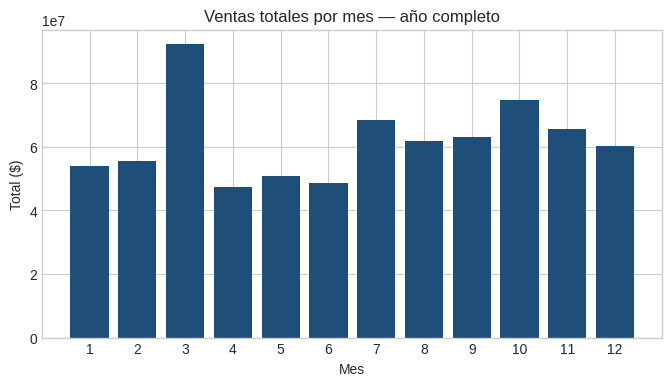

El mes con mayores ventas fue el mes 3, con un total de 92,313,980


In [ ]:
# Reseeamos de nuevo para que este dataset también sea reproducible.
np.random.seed(7)

n2 = 1000
fechas_anio = pd.to_datetime('2026-01-01') + pd.to_timedelta(np.random.randint(0, 365, size=n2), unit='D')
productos_random2 = np.random.choice(list(productos_cat.keys()), size=n2)

datos_anio = pd.DataFrame({
    'fecha': fechas_anio,
    'producto': productos_random2,
    'categoria': [productos_cat[p] for p in productos_random2],
    'region': np.random.choice(regiones, size=n2),
    'cantidad': np.random.randint(1, 8, size=n2),
    'precio_unitario': [precio_base[p] * np.random.uniform(0.9, 1.1) for p in productos_random2],
})
datos_anio['total'] = datos_anio['cantidad'] * datos_anio['precio_unitario']
datos_anio['mes'] = datos_anio['fecha'].dt.month

# Agrupación mensual y visualización rápida como cierre del flujo
ventas_mensuales = datos_anio.groupby('mes')['total'].sum()

plt.figure(figsize=(8, 4))
plt.bar(ventas_mensuales.index, ventas_mensuales.values, color='#1f4e78')
plt.title('Ventas totales por mes — año completo')
plt.xlabel('Mes')
plt.ylabel('Total ($)')
plt.xticks(range(1, 13))
plt.show()

mes_top = ventas_mensuales.idxmax()
print(f'El mes con mayores ventas fue el mes {mes_top}, con un total de {ventas_mensuales.max():,.0f}')

### 📝 Ejercicio — Nivel 3 (mini-proyecto de EDA)

Usando el DataFrame `datos_anio` que acabamos de generar, realiza un análisis exploratorio completo. **Guarda tus respuestas en las variables indicadas:**

1. **Estadísticas descriptivas**: calcula el total vendido, el promedio y la mediana del `total` por `categoria`. → variable **`resumen_categoria`** (con columnas `sum`, `mean`, `median`)
2. **Tabla dinámica**: construye una tabla dinámica de `total` vendido cruzando `region` (filas) y `mes` (columnas). → variable **`tabla_region_mes`**
3. **Visualización (mínimo 2 gráficos)**: por ejemplo, un heatmap de la tabla dinámica y un boxplot de `total` por `categoria`.
4. **Conclusiones**: en una celda de texto (Markdown), escribe 3-4 líneas resumiendo qué región y categoría concentran más ventas, y si notas algún patrón estacional (por mes).

(Los gráficos y las conclusiones no se verifican automáticamente. Las variables `resumen_categoria` y `tabla_region_mes` sí las revisa `verificar_ejercicio_3()`.)

Usa las celdas de abajo (agrega las que necesites).

In [ ]:
resumen_categoria = datos_anio.groupby('categoria')['total'].agg(['sum', 'mean', 'median'])


In [ ]:
tabla_region_mes = datos_anio.pivot_table(
    index='region',
    columns='mes',
    values='total',
    aggfunc='sum',
    fill_value=0
)

/tmp/ipykernel_1235/392675503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos_anio, x='categoria', y='total', palette='pastel', ax=axes[1])


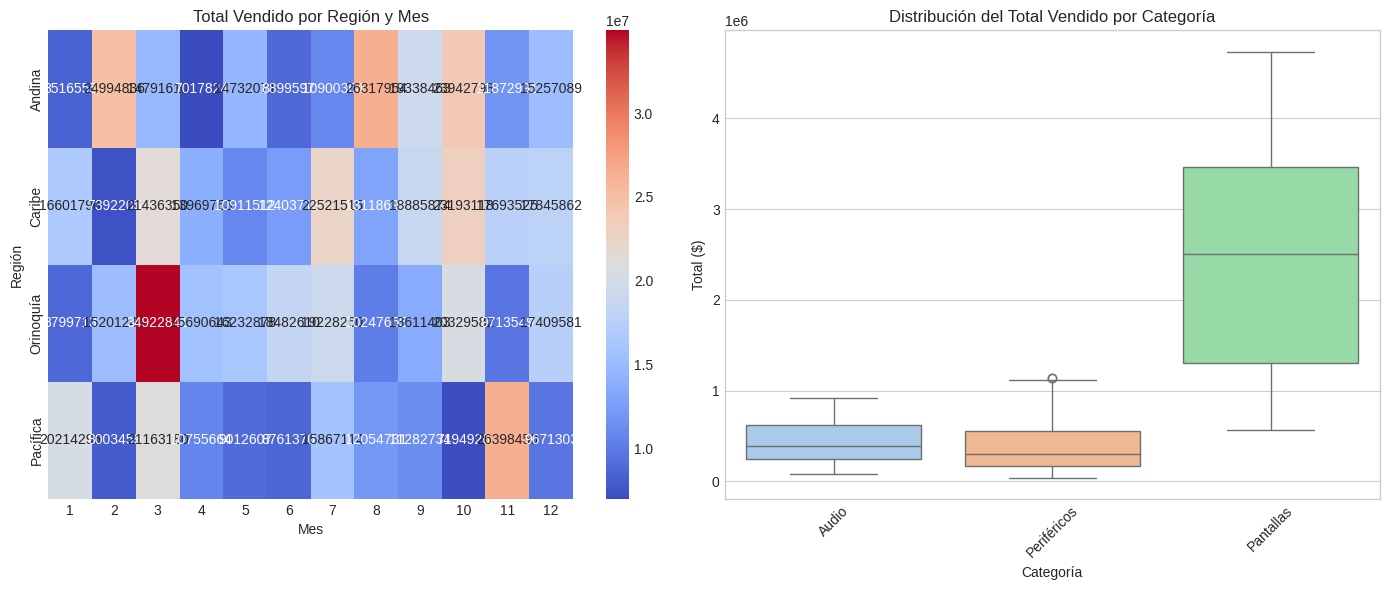

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap de la tabla_region_mes
sns.heatmap(tabla_region_mes, annot=True, fmt='.0f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Total Vendido por Región y Mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Región')

# Boxplot de total por categoria
sns.boxplot(data=datos_anio, x='categoria', y='total', palette='pastel', ax=axes[1])
axes[1].set_title('Distribución del Total Vendido por Categoría')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Total ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Conclusiones del análisis exploratorio de `datos_anio`:

1.  **Categoría principal**: La categoría 'Pantallas' es la que concentra el mayor volumen de ventas totales en el año, superando significativamente a 'Periféricos' y 'Audio'.
2.  **Regiones destacadas**: Al observar la `tabla_region_mes` (y su visualización en el mapa de calor), se evidencia que las regiones de 'Orinoquía' y 'Andina' muestran consistentemente los mayores totales de ventas a lo largo del año.
3.  **Patrón estacional**: Se identifica un claro patrón estacional en las ventas. El **mes de marzo (mes 3)** registra el pico de ventas más alto del año, seguido por **octubre (mes 10)** y **julio (mes 7)**. Esto podría indicar periodos de alta demanda que podrían ser aprovechados con campañas de marketing específicas.

Cuando tengas `resumen_categoria` y `tabla_region_mes` listos, ejecuta esta celda:

In [ ]:
def verificar_ejercicio_3():
    print('Verificando Ejercicio 3...')
    ok = True

    if 'resumen_categoria' in globals():
        filas = sorted([
            [str(idx), round(float(row['sum'])), round(float(row['mean'])), round(float(row['median']))]
            for idx, row in resumen_categoria.iterrows()
        ])
        ok &= _reportar('resumen_categoria', _huella(filas) == '863de91a4b02',
                         'revisa que tengas las columnas sum, mean y median agrupando por categoria')
    else:
        ok = _reportar('resumen_categoria', False, 'no has definido esta variable')

    if 'tabla_region_mes' in globals():
        celdas = sorted([
            [str(region), int(mes), round(float(tabla_region_mes.loc[region, mes]))]
            for region in tabla_region_mes.index
            for mes in tabla_region_mes.columns
        ])
        ok &= _reportar('tabla_region_mes', _huella(celdas) == '7934245916e9',
                         'revisa index, columns, values y aggfunc de tu pivot_table')
    else:
        ok = _reportar('tabla_region_mes', False, 'no has definido esta variable')

    print('🎉 ¡Todo correcto! (recuerda revisar tus gráficos y conclusiones)' if ok else 'Sigue intentando, revisa las pistas de arriba.')

verificar_ejercicio_3()

Verificando Ejercicio 3...
  ✅ resumen_categoria: ¡correcto!
  ✅ tabla_region_mes: ¡correcto!
🎉 ¡Todo correcto! (recuerda revisar tus gráficos y conclusiones)


---
## Cierre

En este repaso trabajamos:

- **NumPy**: arrays y operaciones vectorizadas.
- **Pandas**: creación y exploración de `DataFrame`, selección (`loc`/`iloc`), limpieza (`isna`, `dropna`, `fillna`, `drop_duplicates`), transformación (`apply`, `map`, `astype`), agregación (`groupby`, `agg`, `pivot_table`, `crosstab`) y combinación de tablas (`merge`, `concat`).
- **Matplotlib** y **Seaborn**: gráficos de línea, barras, histograma, boxplot y heatmap, y personalización básica de figuras.

Estas herramientas son la base para el **Módulo 2 — Transformación y visualización de datos**, donde profundizaremos en preprocesamiento y visualización.

### Recursos adicionales
- [Documentación oficial de Pandas](https://pandas.pydata.org/docs/)
- [Documentación oficial de Matplotlib](https://matplotlib.org/stable/index.html)
- [Documentación oficial de Seaborn](https://seaborn.pydata.org/)
- [Pandas Cheat Sheet (oficial)](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)